# (06) pairwise corrs: (16, 20.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from base.helper import ParameterGrid
from utils.animation import show_movie


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Setup feeder params

In [3]:
# Define parameter values

contrast_min = 0.4
contrast_max = 1.0
contrast_delta = 0.4
contrast_num = (contrast_max - contrast_min) / contrast_delta
contrast_num = int(np.ceil(contrast_num)) + 1
contrast = np.linspace(
    start=contrast_min,
    stop=contrast_max,
    num=contrast_num,
)

theta_delta = 5
theta_num = int(np.ceil(180 / theta_delta)) + 1
theta = np.linspace(0, 180, theta_num)

s_freq_min = 0.5
s_freq_max = 6.0
s_freq_delta = 0.5
s_freq_num = (s_freq_max - s_freq_min) / s_freq_delta
s_freq_num = int(np.ceil(s_freq_num)) + 1
s_freq = np.linspace(
    start=s_freq_min,
    stop=s_freq_max,
    num=s_freq_num,
)
s_freq = np.insert(s_freq, obj=0, values=0.1)

params = {
    'contrast': np.round(contrast, decimals=2),
    's_freq': np.round(s_freq, decimals=2),
    'theta': np.round(theta, decimals=2),
}
print(params)

{
    'contrast': array([0.4, 0.7, 1. ]),
    's_freq': array([0.1, 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
    'theta': array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160.,
       165., 170., 175., 180.])
}

### Make param grid

In [4]:
grid = ParameterGrid(params)
param_vectors = grid.get_param_vectors()

shapes = {k: v.shape for k, v in param_vectors.items()}
print(f"Total combinations: {len(grid)}\n{shapes}")

Total combinations: 1443
{'contrast': (1443,), 's_freq': (1443,), 'theta': (1443,)}

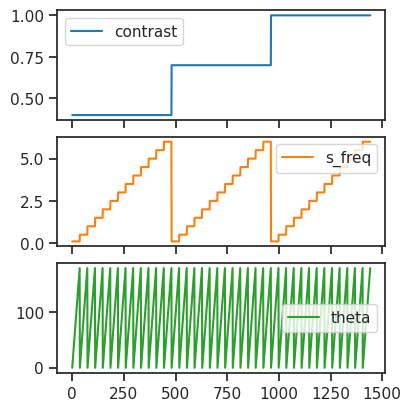

In [5]:
fig, axes = create_figure(3, 1, (4, 4), sharex='all')

intvl = range(len(grid))  # range(1500)

for i, (k, v) in enumerate(param_vectors.items()):
    axes[i].plot(v[intvl], label=k, color=f"C{i}")

add_legend(axes)
plt.show()

### Test if param grid works

In [6]:
idx = 432
params_at_idx = grid[idx]

for k in grid.param_names:
    assert param_vectors[k][idx] == params_at_idx[k]

print(params_at_idx)

{'contrast': 0.4, 's_freq': 5.5, 'theta': 125.0}

In [7]:
recovered_idx = grid.params_to_index(**params_at_idx)

print(f"Recovered index: {recovered_idx}")

Recovered index: 432

In [8]:
print(f"Parameter at index {idx}:\t theta = {grid.get_param_at_index(idx, 'theta')}")

Parameter at index 432:  theta = 125.0

### Make feeder

In [9]:
param_vectors = grid.get_param_vectors()
n_frames_for_full_cycle = 500

feeder_kws = dict(
    npix=16,
    #
    theta=param_vectors['theta'],
    s_freq=param_vectors['s_freq'],
    t_freq=1 / n_frames_for_full_cycle,
    contrast=param_vectors['contrast'],
    normalize_coords=True,
    #
    device=device,
    flatten=False,
)
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

In [10]:
frames = [feeder[t] for t in range(n_frames_for_full_cycle + 1)]
frames = torch.cat(frames, dim=1)
frames.shape

torch.Size([1443, 501, 16, 16])

In [11]:
idx = 600
print(grid[idx])

{'contrast': 0.7, 's_freq': 1.5, 'theta': 40.0}

In [12]:
show_movie(tonp(frames[idx].squeeze()), n_frames=-1, vmin=-1.0, vmax=1.0)

## Load trainer

In [13]:
model_name = 'poisson_vH16_t-16_z-[512]_cl-10,10_<grad|lin>'
fit_name = 'b200-ep300-lr(0.005)_beta(20:0.1)_temp(0.01:0.5)_gr(500)_(2025_03_02,16:19)'

tr, meta = load_model(f"{model_name}/{fit_name}", device)
meta['checkpoint']

300

### Xtract ftrs

In [14]:
feeder_kws['flatten'] = True

In [15]:
%%time

tr.model.cfg.set_seeds(1)

output_1 = tr.model.xtract_ftr(
    feeder=FEEDER_CLASSES['drifting-grating'](**feeder_kws),
    seq=range(2 * n_frames_for_full_cycle),
    return_extras=['samples', 'u', 'r2'],
).stack()


tr.model.cfg.set_seeds(2)

output_2 = tr.model.xtract_ftr(
    feeder=FEEDER_CLASSES['drifting-grating'](**feeder_kws),
    seq=range(2 * n_frames_for_full_cycle),
    return_extras=['samples', 'u', 'r2'],
).stack()

CPU times: user 7.75 s, sys: 154 ms, total: 7.9 s
Wall time: 3.77 s


In [16]:
u_norm_1 = tonp(torch.linalg.norm(output_1['u'], axis=-1))
r_norm_1 = tonp(torch.linalg.norm(torch.exp(output_1['u']), axis=-1))

u_norm_2 = tonp(torch.linalg.norm(output_2['u'], axis=-1))
r_norm_2 = tonp(torch.linalg.norm(torch.exp(output_2['u']), axis=-1))

In [17]:
idx_high_cntrst = grid.params_to_index(contrast=contrast_max, s_freq=4.0, theta=0.0)
idx_low_cntrst = grid.params_to_index(contrast=contrast_min, s_freq=4.0, theta=0.0)

In [18]:
def do_it(output, neuron_i=4):
    firing_rates = torch.exp(output['u'])
    r_norms_time = torch.linalg.norm(firing_rates, dim=1)

    most_active_neurons = np.argsort(tonp(
        r_norms_time[idx_high_cntrst]
    ))[::-1]

    spks_high_contrast = tonp(output['samples'][idx_high_cntrst, :, most_active_neurons[neuron_i]])
    spks_low_contrast = tonp(output['samples'][idx_low_cntrst, :, most_active_neurons[neuron_i]])

    return spks_high_contrast, spks_low_contrast, most_active_neurons


def plot_it(output, neuron_i=4):
    spks_high_contrast, spks_low_contrast, _ = do_it(output, neuron_i)

    intervals = [
        range(300, 300 + n_frames_for_full_cycle),
        range(n_frames_for_full_cycle, 2 * n_frames_for_full_cycle),
    ]
    
    fig, axes = create_figure(1, 2, (9.2, 3))
    for i, intvl in enumerate(intervals):
        x2p = spks_high_contrast[intvl]
        axes[i].plot(intvl, x2p, color='k', label=f'high cntrst (n_spks = {sum(x2p)})')
        x2p = spks_low_contrast[intvl]
        axes[i].plot(intvl, x2p, color='C1', label=f'low cntrst (n_spks = {sum(x2p)})')
    # ax.axvline(500, color='dimgrey', ls='--', label='stimulus onset')
    
    add_legend(axes, fontsize=10)
    add_grid(axes)
    
    plt.show()

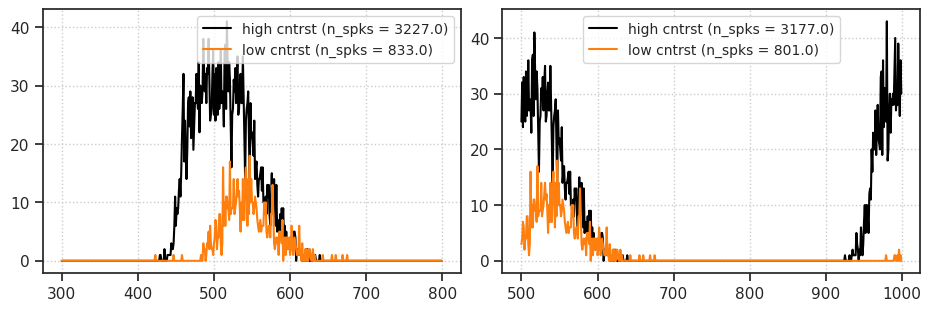

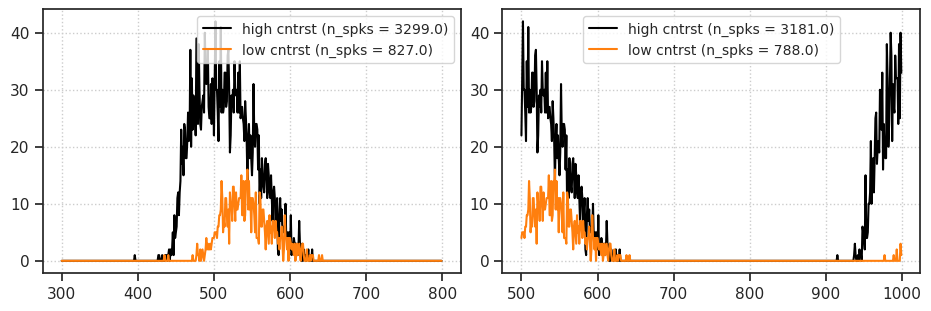

In [19]:
plot_it(output_1)
plot_it(output_2)

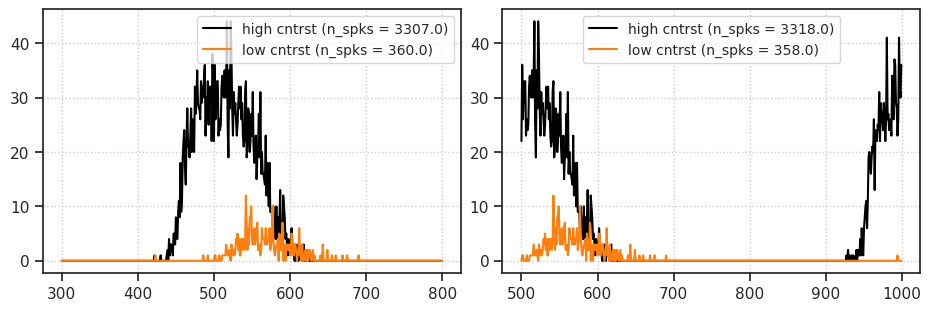

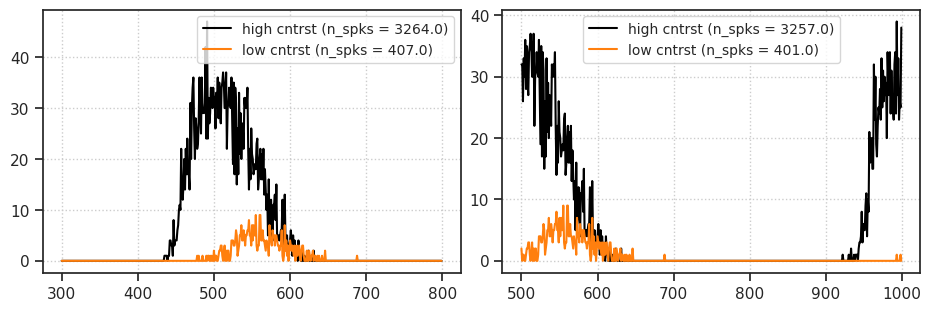

In [19]:
### Was: contrast_min = 0.3

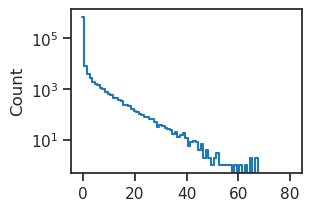

In [20]:
spks = tonp(output_1['samples'][:, -1].ravel()).astype(int)

fig, ax = create_figure()
histplot(spks, bins=np.linspace(0, 81, 82) - 0.5)
ax.set(yscale='log')
plt.show()

In [21]:
spks_high_contrast, spks_low_contrast, most_active_neurons = do_it(output_1)

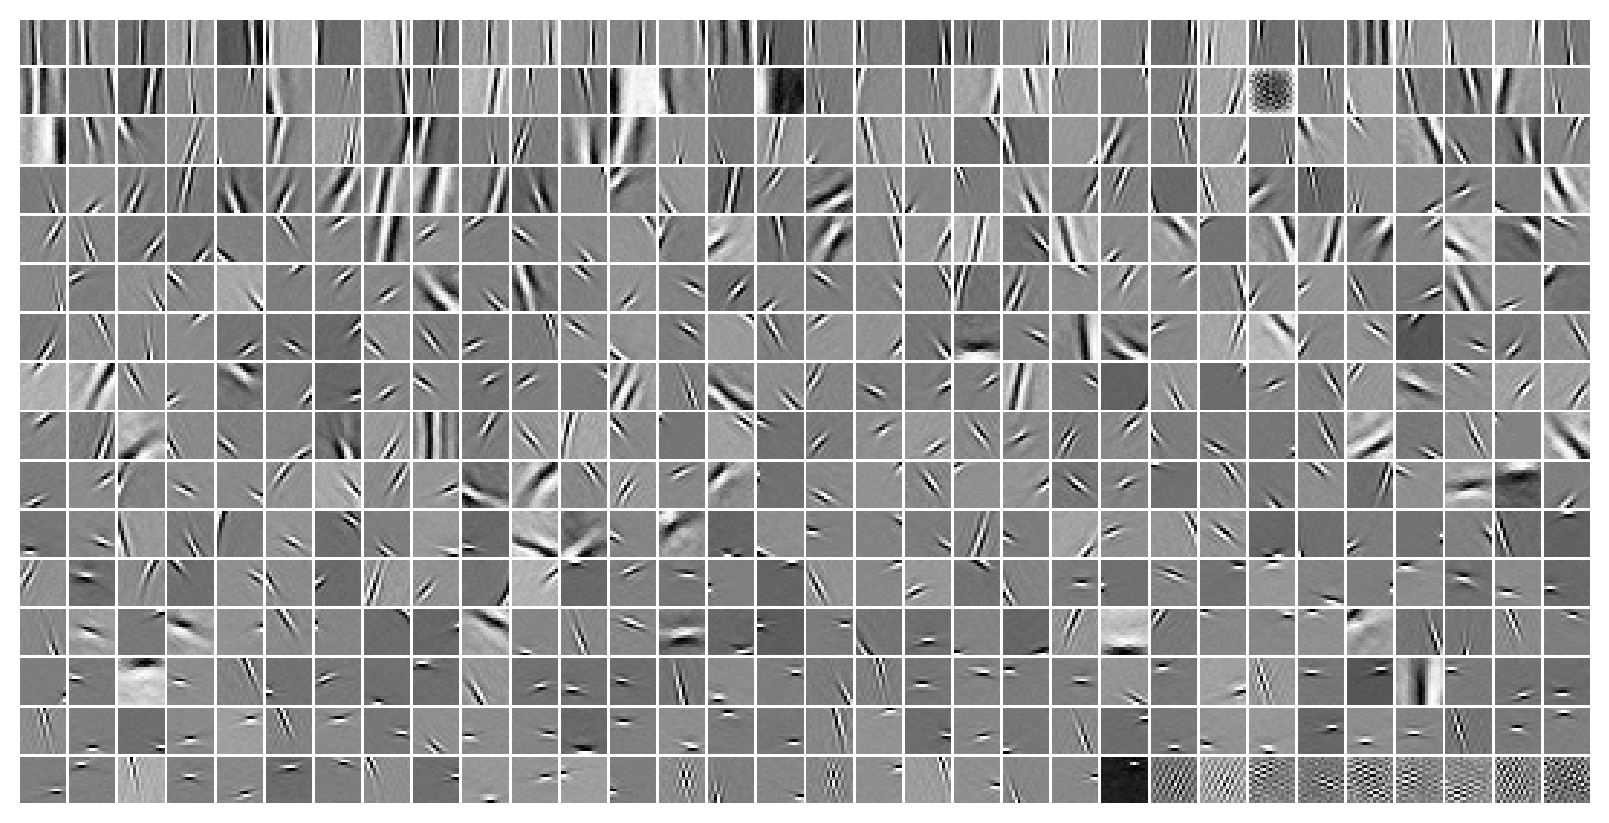

In [22]:
tr.model.show(order=most_active_neurons);

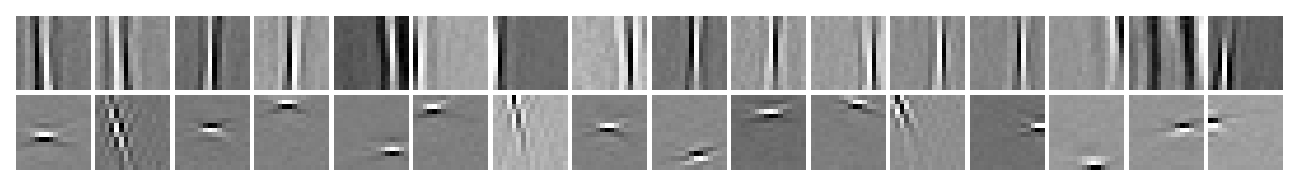

In [23]:
w = tonp(tr.model.layer.get_weight())
w = w.T.reshape(-1, 16, 16)

num = 16
num_skip = 20

x2p = np.concatenate([
    w[most_active_neurons[:num]],
    w[most_active_neurons[-num-num_skip:-num_skip]],
], axis=0)

plot_weights(x2p, nrows=2)
plt.show()

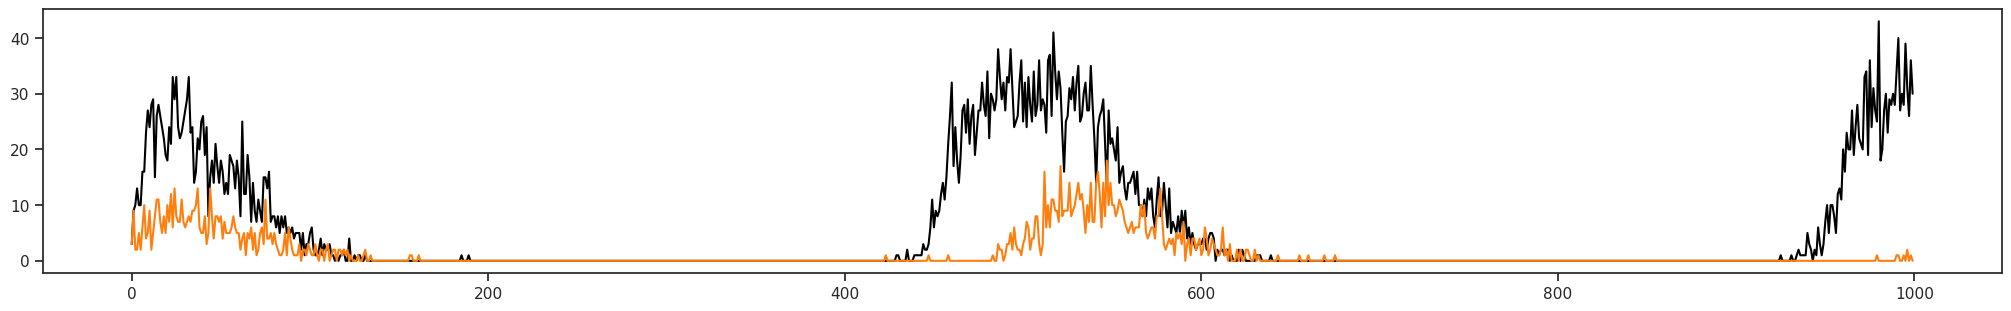

In [26]:
fig, ax = create_figure(1, 1, (20, 3))
plt.plot(spks_high_contrast, color='k')
plt.plot(spks_low_contrast, color='C1')
plt.show()

## Sanity check

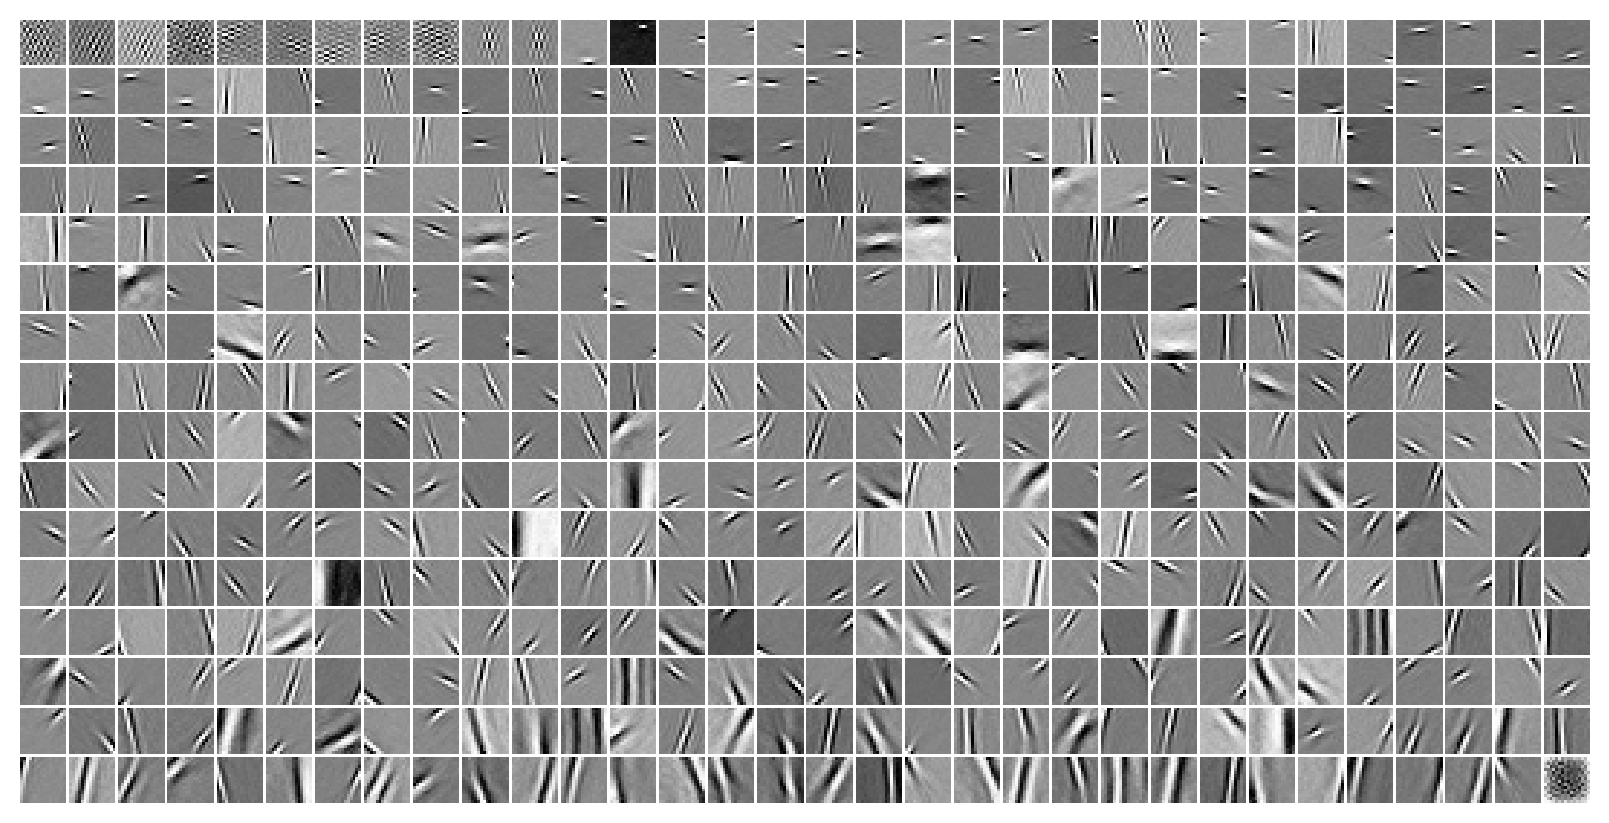

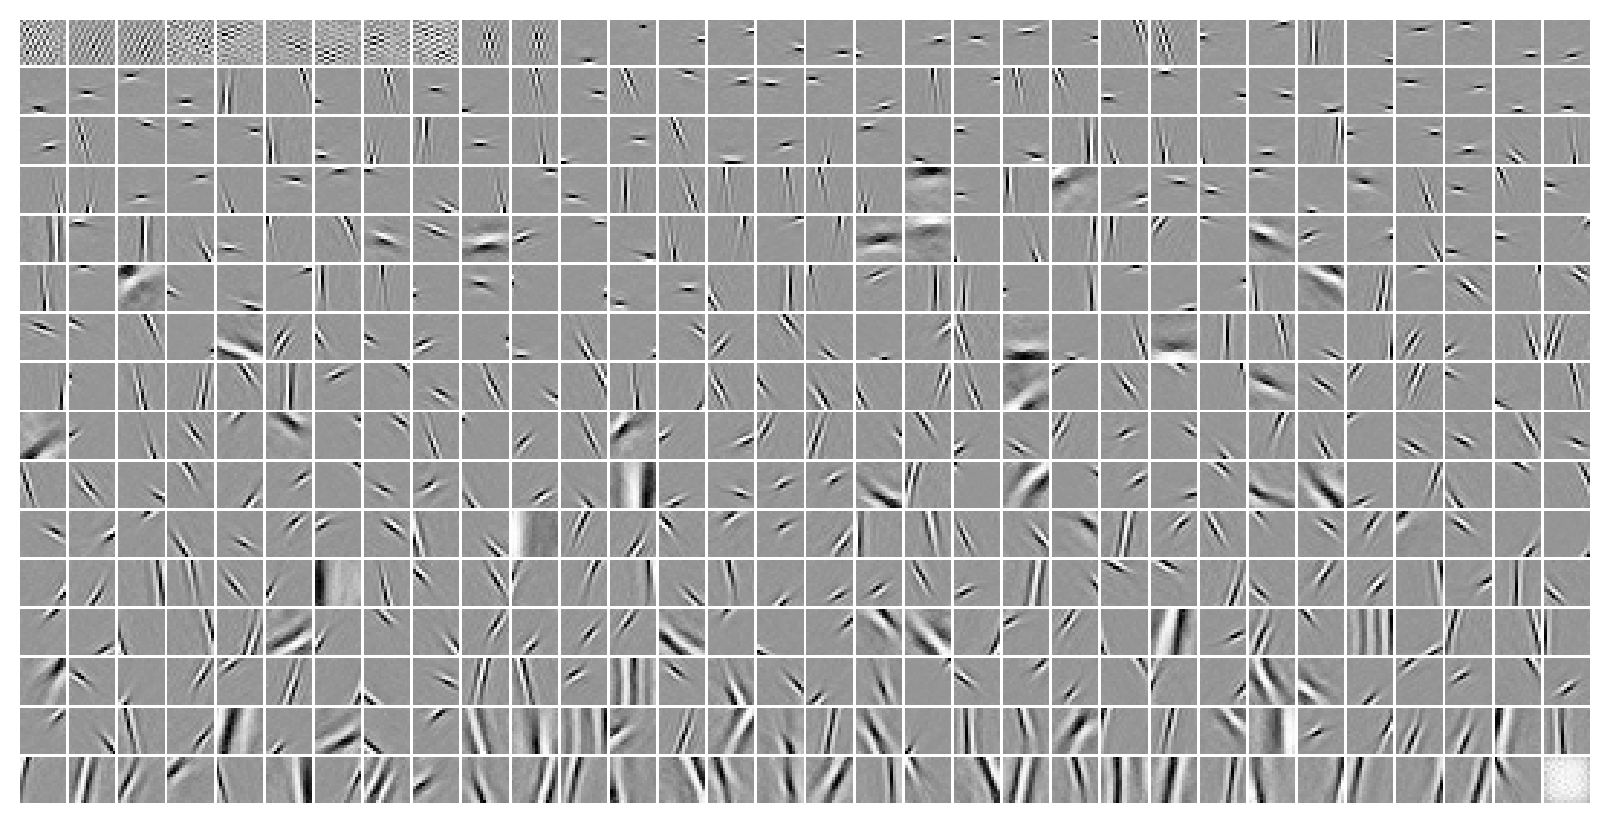

In [4]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0))
tr.model.show(order=np.argsort(u0), method='abs-max');

100%|███████████████████████████████████| 2/2 [00:39<00:00, 19.84s/it]


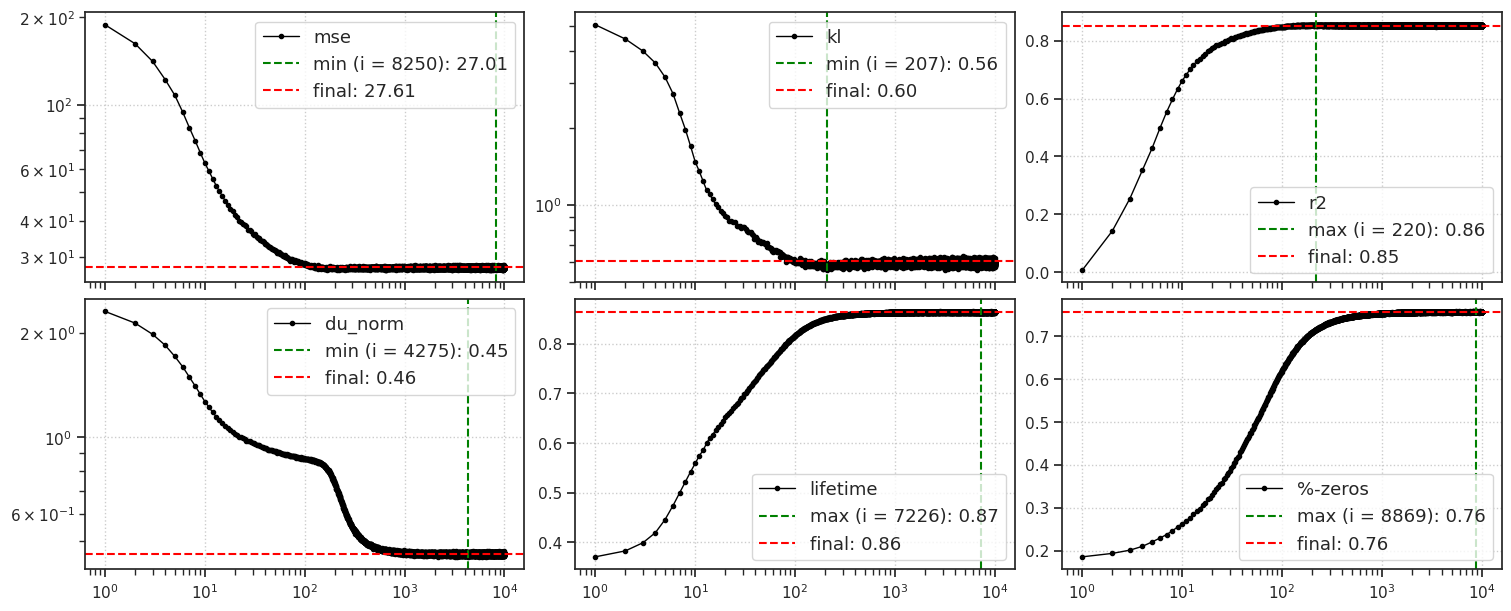

CPU times: user 50.3 s, sys: 3.27 s, total: 53.6 s
Wall time: 53.6 s


In [5]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')